<a href="https://colab.research.google.com/github/sreenathsnv/AI-ML/blob/ML-models/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **K-MEANS CLUSTERING**



##### 1.  Choose a random K value ( number of centroid is equal to number of clusters)
##### 2. Initialize K number of centroids from the dataset randomly
##### 3. Compute the distance from each point to those k centroids
##### 4. Assign the point to the cluster belongs to the nearest centroid
##### 5. measure the average for each cluster and that become the new centroid


## ELBOW METHOD

The Elbow Method is a popular technique to help decide the optimal number of clusters (k) for K-Means


---

## 1. Concept

K-Means tries to minimize the **within-cluster sum of squared distances (WCSS)**:

$$
\text{WCSS} = \sum_{i=1}^{k} \sum_{x \in C_i} \|x - c_i\|^2
$$

- $C_i$ = points in cluster $i$  
- $c_i$ = centroid of cluster $i$  
- $\|x - c_i\|^2$ = squared distance from point to its cluster centroid

**Idea:**

- As `k` increases, WCSS **decreases**, because more clusters mean points are closer to centroids.  
- But after a certain point, adding more clusters doesn’t significantly reduce WCSS.  

---

## 2. Steps of the Elbow Method

1. **Run K-Means** for different values of `k` (e.g., 1 to 10).  
2. **Calculate WCSS** for each `k`.  
3. **Plot k vs. WCSS**.  
4. Look for the **“elbow point”**, where the rate of decrease sharply slows.  

- This “elbow” indicates the **optimal number of clusters**.  
- Before the elbow → adding clusters significantly reduces WCSS.  
- After the elbow → adding clusters gives diminishing returns.  

---

# **HIERARCHICAL CLUSTERING**

# Hierarchical Clustering

Hierarchical Clustering is an **unsupervised machine learning algorithm** used to group similar data points into clusters.  
Unlike K-Means, it **does not require specifying the number of clusters beforehand**. Instead, it creates a **tree-like structure called a dendrogram** that shows how clusters are formed.

Often Associated with heatmap

---

## Types of Hierarchical Clustering

### 1. Agglomerative Clustering (Bottom-Up Approach)
- Each data point starts as its **own cluster**.
- The algorithm **merges the closest clusters step by step**.
- This continues until all points belong to **one cluster**.

Steps:
1. Start with **N clusters** (each data point is a cluster).
2. Compute the **distance between clusters**.
3. Merge the **two closest clusters**.
4. Repeat until **only one cluster remains**.

---

### 2. Divisive Clustering (Top-Down Approach)
- Start with **all data points in one cluster**.
- Recursively **split clusters into smaller clusters**.
- Continue until **each data point becomes its own cluster**.

---

## Distance Metrics Used

Common distance measures:

- **Euclidean Distance**
- **Manhattan Distance**
- **Cosine Distance**

Example (Euclidean Distance):

$$
d(x,y) = \sqrt{\sum (x_i - y_i)^2}
$$

---

## Linkage Methods

Linkage defines **how the distance between clusters is calculated**.

1. **Single Linkage**
   - Distance between the **closest points** of two clusters.

2. **Complete Linkage**
   - Distance between the **farthest points** of two clusters.

3. **Average Linkage**
   - Average distance between all pairs of points in the two clusters.

4. **Ward's Method**
   - Minimizes the **variance within clusters**.

---

## Dendrogram

A **dendrogram** is a tree-like diagram used to visualize hierarchical clustering.

- The **x-axis** represents the **data points**.
- The **y-axis** represents the **distance at which clusters are merged**.
- The height of the branches shows **how far apart clusters are** when they are joined.

---

## Finding the Number of Clusters Using the Horizontal Line Technique

The **horizontal line technique** is used to determine the **optimal number of clusters from a dendrogram**.

### Steps:

1. Look at the dendrogram and identify the **largest vertical distance between cluster merges**.
2. Draw a **horizontal line across the dendrogram** at that distance.
3. Count the **number of vertical lines intersected by the horizontal line**.
4. The number of intersections represents the **optimal number of clusters**.

### Example:

If a horizontal line intersects **3 vertical branches**, then the dataset should be divided into **3 clusters**.

**Key Idea:**

Choose the horizontal line where it **cuts the maximum vertical distance without crossing many merges**, as this indicates well-separated clusters.

---

## Advantages

- No need to specify **number of clusters initially**.
- Produces a **hierarchical structure of clusters**.
- Easy to visualize relationships using a **dendrogram**.

---

## Disadvantages

- **Computationally expensive** for large datasets.
- Once clusters are merged or split, the decision **cannot be reversed**.
- Sensitive to **noise and outliers**.

---

## Applications

- **Customer segmentation**
- **Gene sequence analysis**
- **Document clustering**
- **Image segmentation**

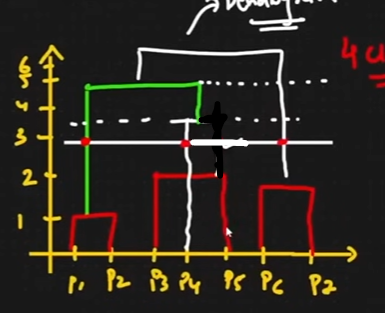

# SILHOUETTE CLUSTERING ( Validating cluster model)





# Silhouette Method for Clustering

The **Silhouette Method** is used to evaluate the **quality of clustering** and to help determine the **optimal number of clusters (k)** in clustering algorithms such as **K-Means**.

It measures how well each data point fits **within its own cluster** compared to **other clusters**.

---

# Silhouette Score Formula

For a data point \(i\):

$$
s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

Where:

- \(a(i)\) = **Average intra-cluster distance**
- \(b(i)\) = **Average nearest-cluster distance**

The silhouette score ranges between **-1 and +1**.

---

# Understanding \(a(i)\) (Intra-cluster Distance)

\(a(i)\) measures **how close a data point is to other points within the same cluster**.

It is calculated as the **average distance between point \(i\) and all other points in its cluster**.

If point \(i\) belongs to cluster \(C\) containing \(n\) points:

$$
a(i) = \frac{1}{n-1} \sum_{j \in C, j \neq i} d(i,j)
$$

Where:

- \(d(i,j)\) = distance between point \(i\) and point \(j\)
- \(n\) = number of points in cluster \(C\)

### Interpretation

- **Small \(a(i)\)** → point is close to its cluster members (good clustering).
- **Large \(a(i)\)** → point is far from its cluster members (poor clustering).

---

# Understanding \(b(i)\) (Nearest Cluster Distance)

\(b(i)\) measures **how far the point is from points in the nearest neighboring cluster**.

To calculate \(b(i)\):

1. Compute the **average distance from point \(i\) to all points in another cluster**.
2. Repeat this for all other clusters.
3. Select the **minimum of these average distances**.

Mathematically:

$$
b(i) = \min_{C_k \neq C_i}
\left(
\frac{1}{|C_k|} \sum_{j \in C_k} d(i,j)
\right)
$$

Where:

- \(C_i\) = cluster containing point \(i\)
- \(C_k\) = another cluster
- \(|C_k|\) = number of points in cluster \(C_k\)

### Interpretation

- **Large \(b(i)\)** → point is far from other clusters (good).
- **Small \(b(i)\)** → point is close to another cluster (possible misclassification).

---

# Silhouette Score Interpretation

| Silhouette Score | Meaning |
|------------------|--------|
| **+1** | Point is well matched to its own cluster and far from others |
| **0** | Point lies between clusters |
| **-1** | Point may be assigned to the wrong cluster |

---

# Using Silhouette Method to Find Optimal Clusters

Steps:

1. Select a range of cluster values (e.g., **k = 2 to 10**).
2. Run the clustering algorithm for each \(k\).
3. Compute the **average silhouette score** for all data points.
4. Plot **k vs average silhouette score**.
5. The **k with the highest silhouette score** is considered the **optimal number of clusters**.

---

# Key Idea

Good clustering should have:

- **Low intra-cluster distance** → small \(a(i)\)
- **High inter-cluster distance** → large \(b(i)\)

This results in a **silhouette score close to +1**, indicating well-separated clusters.

---

# Advantages

- Evaluates **cluster cohesion and separation simultaneously**.
- Helps **identify the best number of clusters**.
- Works with different clustering algorithms.

---

# Limitations

- Computationally expensive for **large datasets**.
- Works best when clusters are **well separated and compact**.

---

# Applications

- Customer segmentation  
- Market analysis  
- Image segmentation  
- Pattern recognition  

# **DBSCAN CLUSTERING** - **D**ensity **B**ased **S**patial **C**lustering of **A**pplication With **N**oise



## Overview
DBSCAN is a **density-based clustering algorithm** used in machine learning and data mining.  
It groups together points that are **closely packed** while marking points in **low-density regions as noise (outliers)**.

Unlike centroid-based algorithms such as **K-Means**, DBSCAN:
- Does **not require the number of clusters beforehand**
- Can detect **clusters of arbitrary shape**
- Can automatically **identify noise points**

---

# Mathematical Concepts in DBSCAN

## Epsilon Neighborhood

For a given point \(p\), the **epsilon neighborhood** is defined as:

$$
N_{\varepsilon}(p) = \{ q \in D \mid dist(p,q) \le \varepsilon \}
$$

Where:

- \(D\) = dataset  
- \(dist(p,q)\) = distance between points \(p\) and \(q\)  
- \(\varepsilon\) = radius threshold

This means **all points within distance ε from point p belong to its neighborhood**.

---

## 1. Core Points

A **Core Point** is a point that has **at least MinPts points in its epsilon neighborhood**.

Mathematically:

$$
|N_{\varepsilon}(p)| \ge MinPts
$$

Where:

- \(N_{\varepsilon}(p)\) = epsilon neighborhood of point \(p\)  
- \(|N_{\varepsilon}(p)|\) = number of points in the neighborhood  

### Properties
- Core points represent **dense regions**
- They can **expand clusters**
- They serve as **starting points for cluster formation**

---

## 2. Min Points (MinPts)

**MinPts** is the **minimum number of points required within the epsilon neighborhood** for a point to be considered a **core point**.

### Mathematical Role

$$
|N_{\varepsilon}(p)| \ge MinPts
$$

Typical guideline:

$$
MinPts \ge d + 1
$$

Where:

- \(d\) = number of dimensions in the dataset

Example:

| Dimensions | Recommended MinPts |
|------------|-------------------|
| 2D | 4 |
| 3D | 5 |
| High dimensional | ≥ 2 × dimensions |

Increasing **MinPts** results in **denser clusters**.

---

## 3. Border Points

A **Border Point** is a point that:

- Lies inside the **epsilon neighborhood of a core point**
- But **does not satisfy the core point condition itself**

Mathematically:

$$
|N_{\varepsilon}(p)| < MinPts
$$

but

$$
p \in N_{\varepsilon}(core\ point)
$$

### Characteristics
- Cannot start a cluster
- Belongs to a cluster because it is **density reachable from a core point**

---

## 4. Noise Points (Outliers)

A **Noise Point** is a point that is:

- **Not a core point**
- **Not density reachable from any core point**

Mathematically:

$$
|N_{\varepsilon}(p)| < MinPts
$$

and

$$
p \notin N_{\varepsilon}(core\ points)
$$

### Characteristics
- Lies in **low-density regions**
- Considered **outliers**
- Not assigned to any cluster

---

## 5. Epsilon (ε)

**Epsilon (ε)** is the **maximum distance between two points for them to be considered neighbors**.

Mathematically:

$$
dist(p,q) \le \varepsilon
$$

Common distance metric used:

### Euclidean Distance

$$
dist(p,q) = \sqrt{\sum_{i=1}^{n}(p_i - q_i)^2}
$$

Where:

- \(p_i\) and \(q_i\) are coordinates of points  
- \(n\) = number of dimensions

---

# Density Reachability

A point \(q\) is **directly density reachable** from point \(p\) if:

1. \(p\) is a **core point**
2. \(q \in N_{\varepsilon}(p)\)

Mathematically:

$$
q \in N_{\varepsilon}(p)
$$

---

# Density Connectivity

Two points \(p\) and \(q\) are **density connected** if there exists a chain of points:

$$
p_1, p_2, ..., p_n
$$

such that each point is **density reachable from the previous one**.

This property allows DBSCAN to form **arbitrarily shaped clusters**.

---

# Summary Table

| Term | Mathematical Condition | Description |
|-----|-----|-----|
| Core Point | \( |N_{\varepsilon}(p)| \ge MinPts \) | Point in dense region |
| Border Point | \( |N_{\varepsilon}(p)| < MinPts \) but near core point | Edge of cluster |
| Noise Point | Not density reachable | Outlier |
| MinPts | Minimum neighbor count | Density threshold |
| Epsilon | \(dist(p,q) \le \varepsilon\) | Neighborhood radius |

---

# Advantages of DBSCAN

- No need to specify number of clusters
- Works well for **arbitrarily shaped clusters**
- Detects **outliers automatically**
- Robust to noise

---

# Limitations

- Sensitive to **ε (epsilon) selection**
- Struggles with **varying density datasets**
- Performance decreases in **high-dimensional data**

---

# Applications

- Anomaly detection
- Spatial data analysis
- Image segmentation
- Geographic clustering
- Fraud detection

---

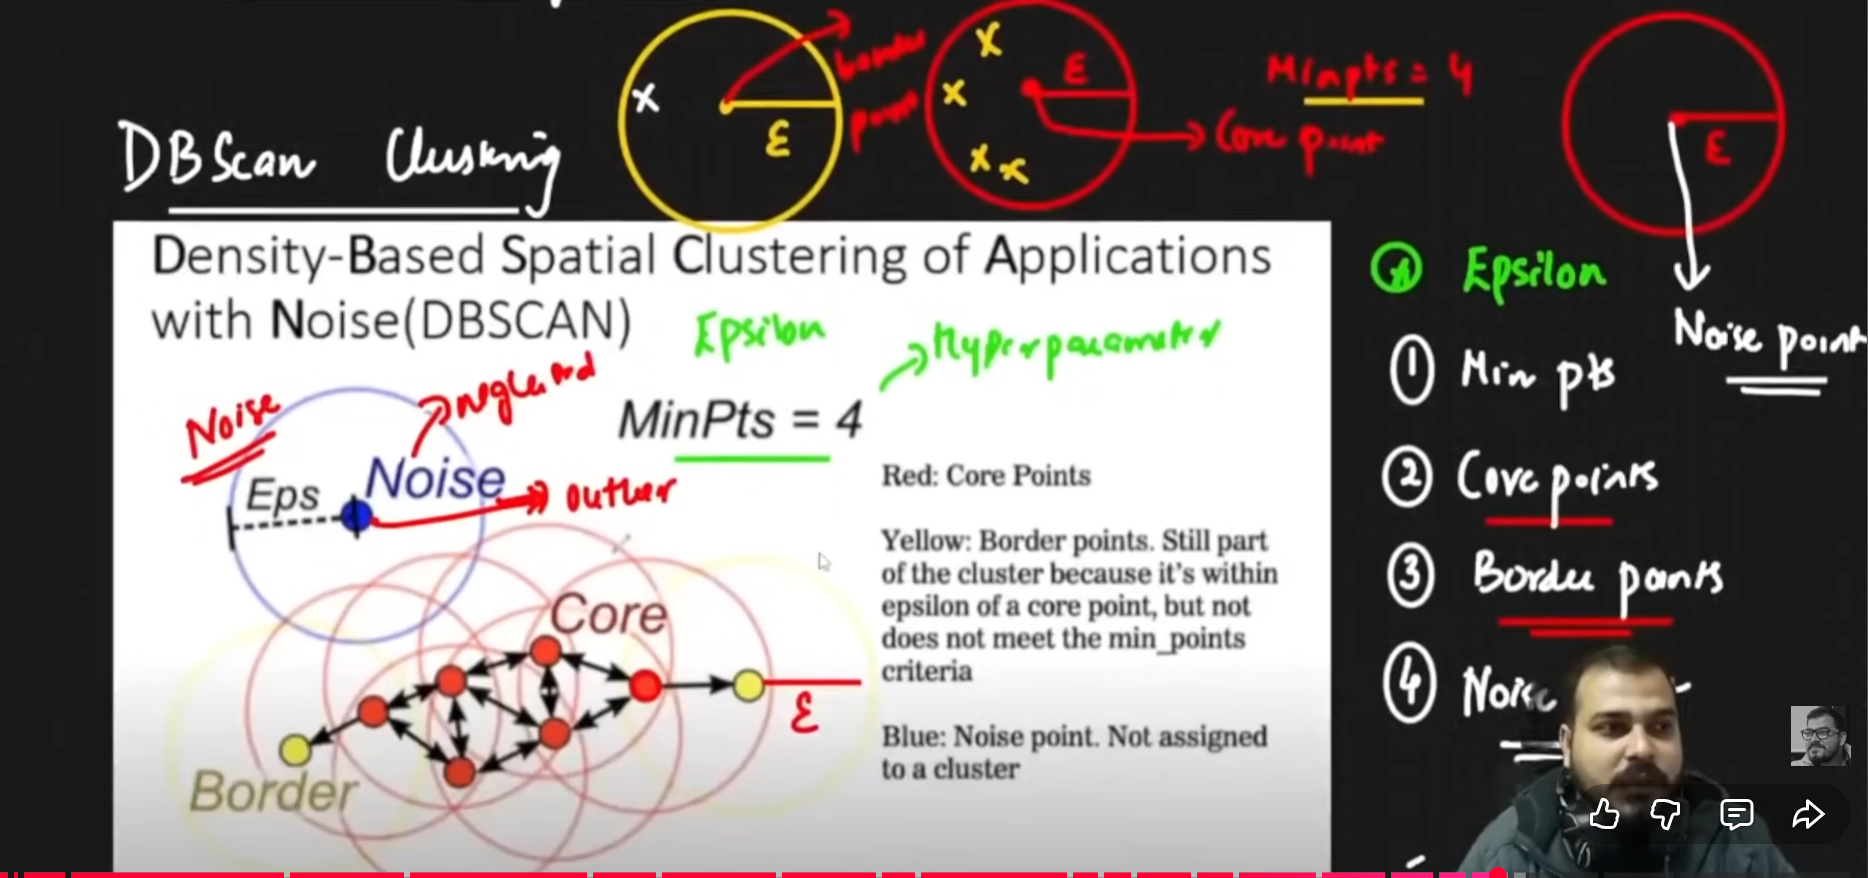

# CODE IMPLEMENTATION

## **KMEANS**

In [ ]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score,silhouette_samples

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np


In [ ]:
X,y  = make_blobs(
    n_samples=600,
    n_features=3,
    centers=4,
    cluster_std=1,
    center_box=(-10,10),
    shuffle=True,
    random_state=42

)
range_n_clusters = [2,3,4,5,6]

In [ ]:
X

array([[  6.31875977, -10.19402504,  10.14029242],
       [  4.88040487,  -8.59226243,   8.64140195],
       [  3.12244301,  -7.58280362,  -6.91509808],
       ...,
       [  1.78918635,  -6.86119326,  -6.53252789],
       [ -8.67775378,   7.32656894,   2.4592384 ],
       [  1.07856238,  -7.06649884,  -7.31984065]])

In [ ]:
y

array([3, 3, 1, 3, 2, 2, 3, 0, 3, 3, 1, 2, 0, 3, 0, 1, 0, 3, 0, 3, 2, 0,
       2, 0, 3, 3, 2, 1, 1, 0, 0, 3, 1, 1, 2, 1, 2, 2, 0, 1, 1, 1, 3, 2,
       3, 1, 1, 0, 0, 1, 3, 3, 0, 3, 0, 3, 3, 1, 1, 1, 0, 3, 3, 0, 0, 3,
       0, 3, 1, 1, 1, 0, 0, 0, 0, 1, 0, 2, 1, 3, 1, 2, 1, 0, 3, 3, 2, 3,
       3, 3, 3, 3, 1, 1, 0, 1, 2, 0, 2, 1, 2, 1, 3, 2, 0, 2, 2, 0, 2, 0,
       3, 2, 2, 3, 3, 2, 2, 1, 3, 0, 0, 0, 1, 1, 1, 2, 3, 0, 1, 0, 3, 2,
       1, 3, 1, 2, 3, 3, 0, 3, 2, 3, 3, 1, 3, 3, 2, 0, 1, 3, 0, 2, 0, 2,
       1, 3, 3, 0, 1, 0, 1, 1, 1, 0, 0, 2, 3, 3, 0, 2, 0, 3, 3, 0, 3, 3,
       2, 1, 3, 2, 1, 2, 0, 3, 2, 3, 2, 1, 0, 0, 3, 0, 0, 0, 2, 0, 1, 1,
       3, 3, 3, 3, 0, 2, 0, 1, 1, 0, 3, 3, 3, 3, 1, 0, 3, 3, 2, 0, 2, 1,
       0, 3, 1, 0, 2, 1, 3, 0, 2, 1, 3, 0, 0, 1, 0, 1, 2, 3, 3, 2, 2, 2,
       2, 1, 2, 3, 2, 1, 1, 1, 1, 2, 0, 0, 1, 1, 3, 0, 0, 0, 1, 2, 3, 2,
       3, 0, 3, 2, 2, 0, 0, 0, 0, 0, 3, 2, 1, 1, 0, 2, 2, 1, 3, 2, 1, 2,
       2, 2, 1, 3, 3, 0, 3, 0, 1, 0, 1, 0, 3, 0, 1,

Text(0, 0.5, 'wcss')

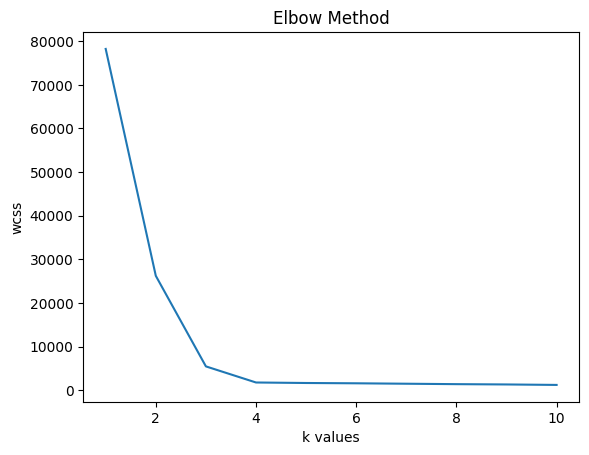

In [ ]:
wcss = []
for i in range(1,11):
  kmeans = KMeans(n_clusters=i,init="k-means++",random_state=0)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss)
plt.title("Elbow Method")
plt.xlabel("k values")
plt.ylabel("wcss")

# We will take last abrupt point

In [ ]:
wcss

[78244.1819138457,
 26217.710014706594,
 5445.662852891753,
 1754.5058464013891,
 1638.9576745370582,
 1569.7520824206756,
 1471.1046413695683,
 1373.3587115733105,
 1303.9073179975053,
 1197.0666866887666]

Silhouette Score: 0.78


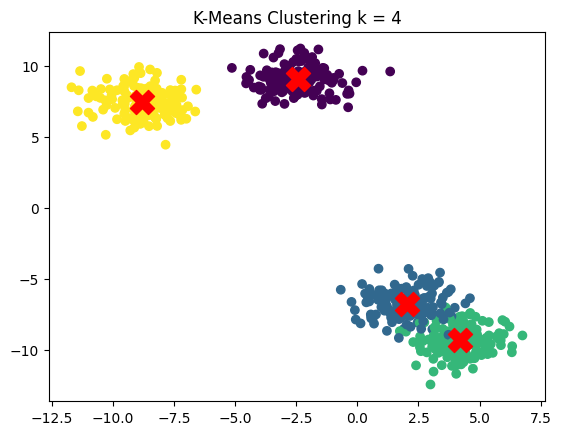

In [ ]:
# Calculate silhouette score for validating the k value

kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X)
# Calculate Silhouette Score
sil_score = silhouette_score(X, labels)
print(f"Silhouette Score: {sil_score:.2f}")
# print(f"Cluster centers: {kmeans.cluster_centers_}")
# print (f'labels : {labels}')
# Visualize Clusters
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='X')
plt.title("K-Means Clustering k = 4")
plt.show()

In [ ]:
scores = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    scores.append(silhouette_score(X, labels))

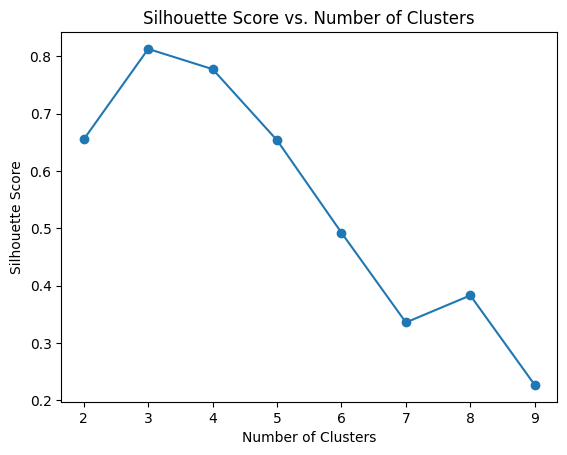

In [ ]:
plt.plot(range(2, 10), scores, marker='o')
plt.title("Silhouette Score vs. Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

observation from the above graph we can see that k =3 is the optimal value for clustering

Silhouette Score: 0.78


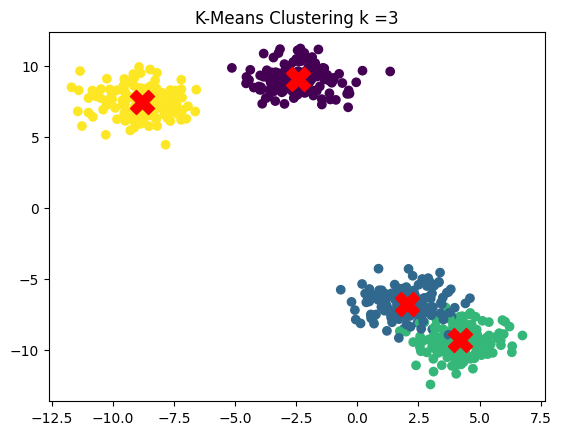

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X)
# Calculate Silhouette Score
sil_score = silhouette_score(X, labels)
print(f"Silhouette Score: {sil_score:.2f}")
# print(f"Cluster centers: {kmeans.cluster_centers_}")
# print (f'labels : {labels}')
# Visualize Clusters
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='X')
plt.title("K-Means Clustering k =3")
plt.show()

For k = 2, the average silhouette_score is : 0.66


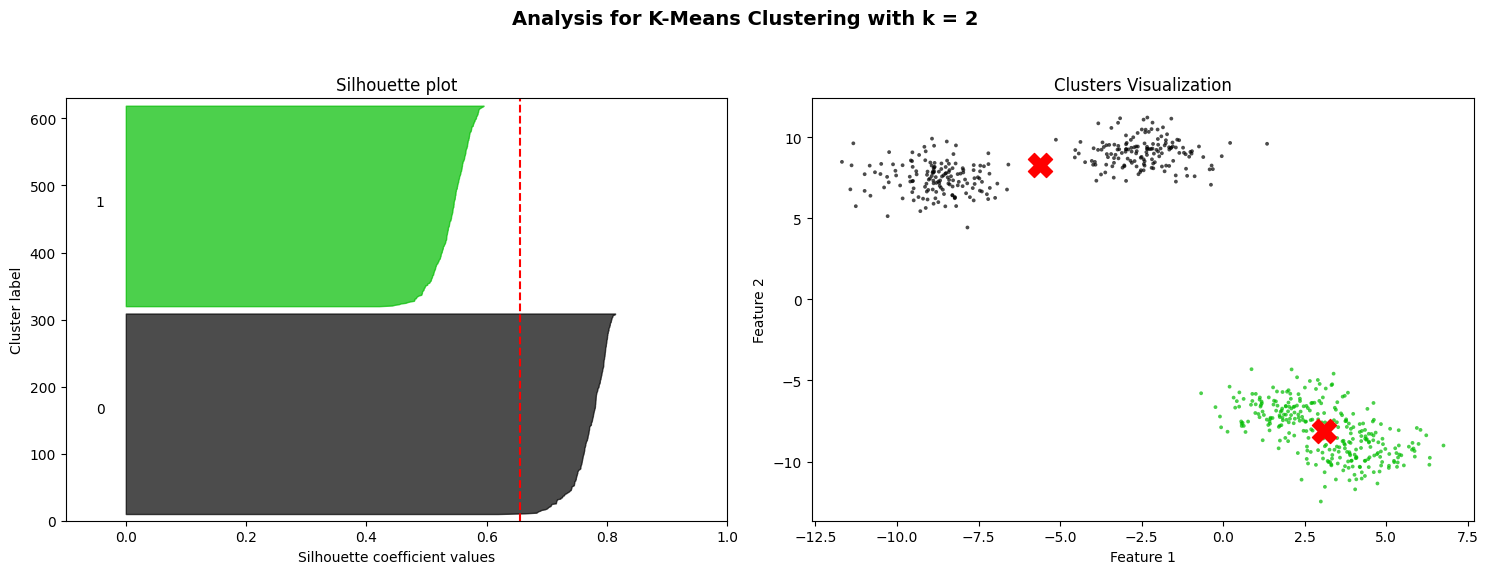

For k = 3, the average silhouette_score is : 0.81


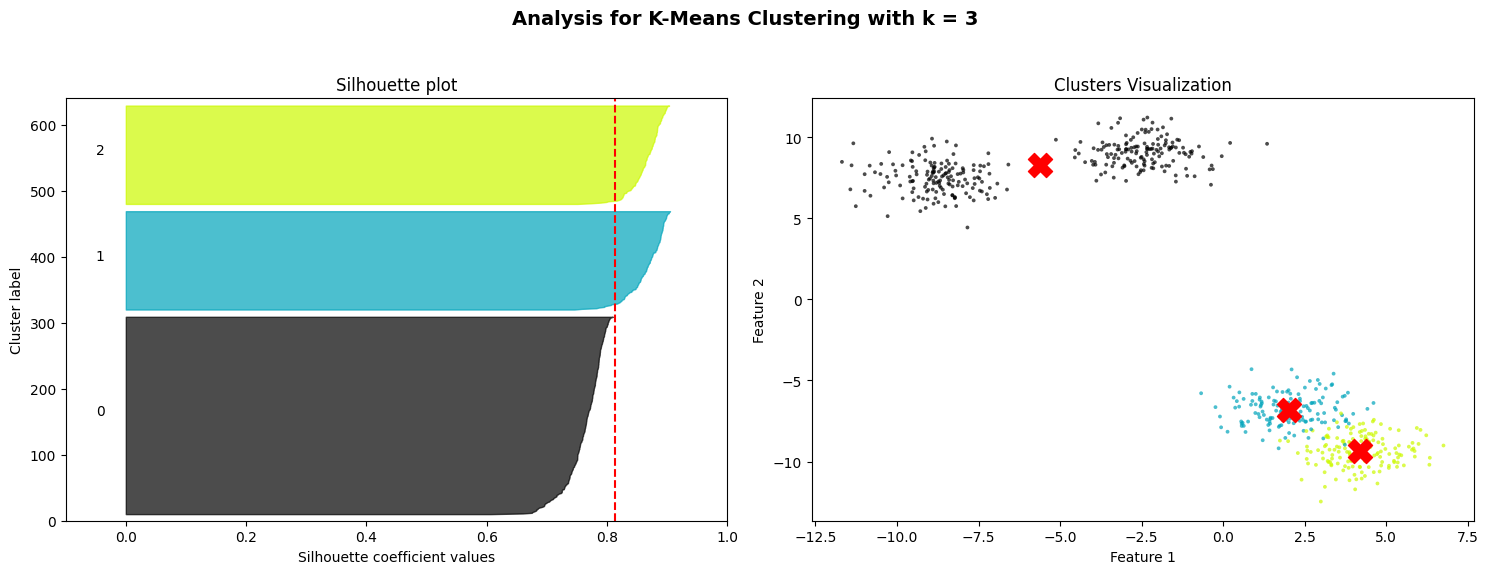

For k = 4, the average silhouette_score is : 0.78


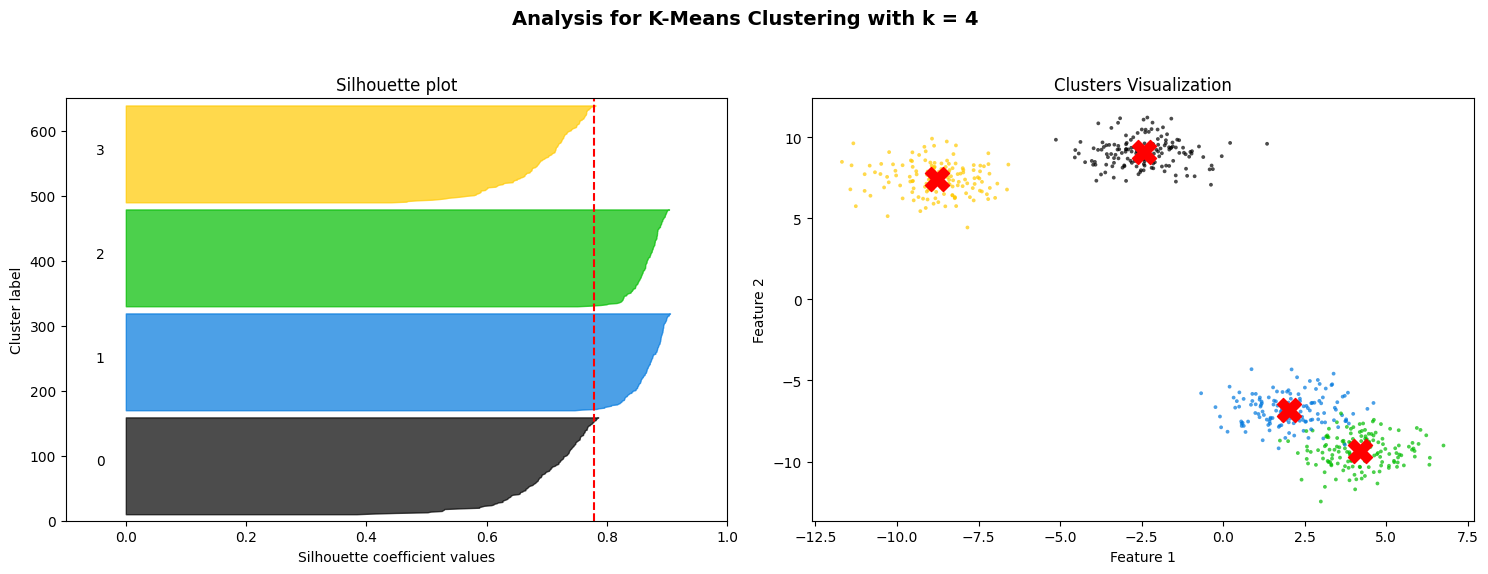

For k = 5, the average silhouette_score is : 0.62


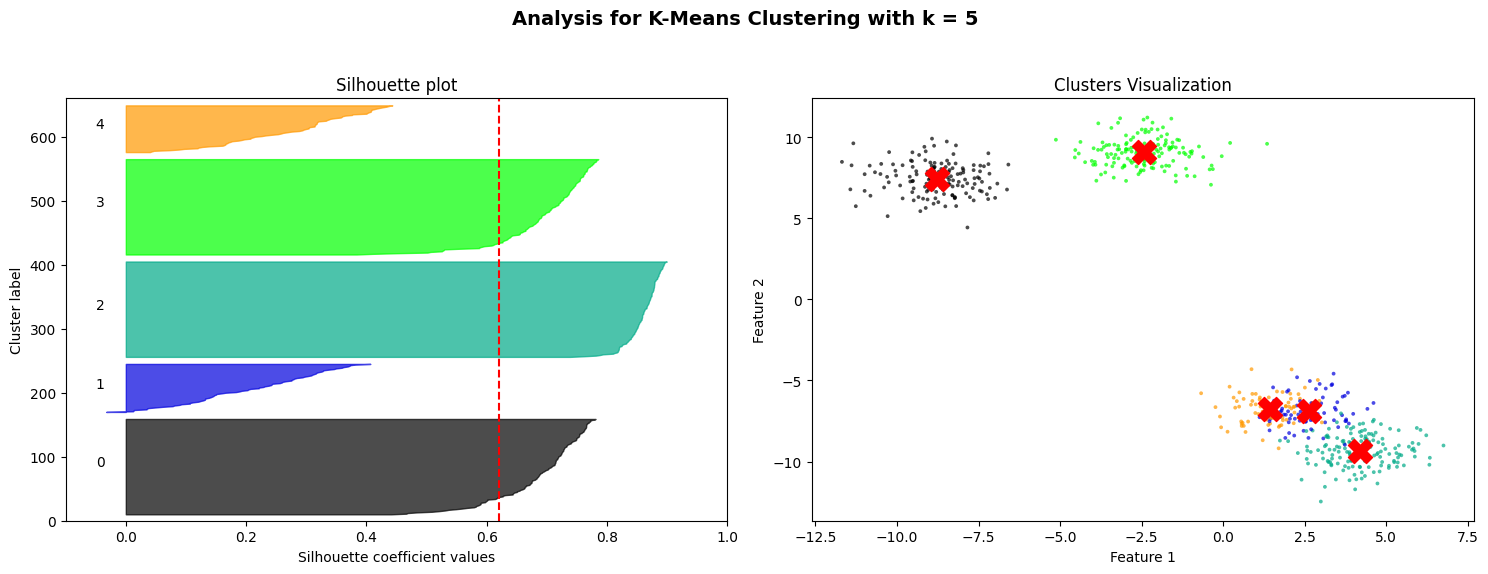

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

# Create plots for each k value
for k in range(2, 6):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f"Analysis for K-Means Clustering with k = {k}", fontsize=14, fontweight="bold")

    # Perform KMeans clustering
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Added n_init to suppress future warning
    labels = kmeans.fit_predict(X)
    cluster_centers = kmeans.cluster_centers_

    # Calculate the average silhouette score
    silhouette_avg = silhouette_score(X, labels)
    print(f"For k = {k}, the average silhouette_score is : {silhouette_avg:.2f}")

    # Calculate individual silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, labels)

    # ------------------- Plot 1: Silhouette plot -------------------
    ax1.set_xlim([-0.1, 1]) # Silhouette coefficients typically range from -1 to 1
    # The (k+1)*10 is to insert blank space between silhouette plots of individual clusters, to make them stand out.
    ax1.set_ylim([0, len(X) + (k + 1) * 10])

    y_lower = 10
    for i in range(k):
        # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
        ith_cluster_silhouette_values = \
            sample_silhouette_values[labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / k)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("Silhouette plot")
    ax1.set_xlabel("Silhouette coefficient values")
    ax1.set_ylabel("Cluster label")
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")


    # ------------------- Plot 2: Scatter plot of clusters -------------------
    colors = cm.nipy_spectral(labels.astype(float) / k)
    ax2.scatter(X[:, 0], X[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k")

    # Plot the centroids as a red 'X'
    ax2.scatter(
        cluster_centers[:, 0],
        cluster_centers[:, 1],
        marker="X",
        c="red",
        alpha=1,
        s=300,
    )

    ax2.set_title("Clusters Visualization")
    ax2.set_xlabel("Feature 1")
    ax2.set_ylabel("Feature 2")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

##  DBSCAN

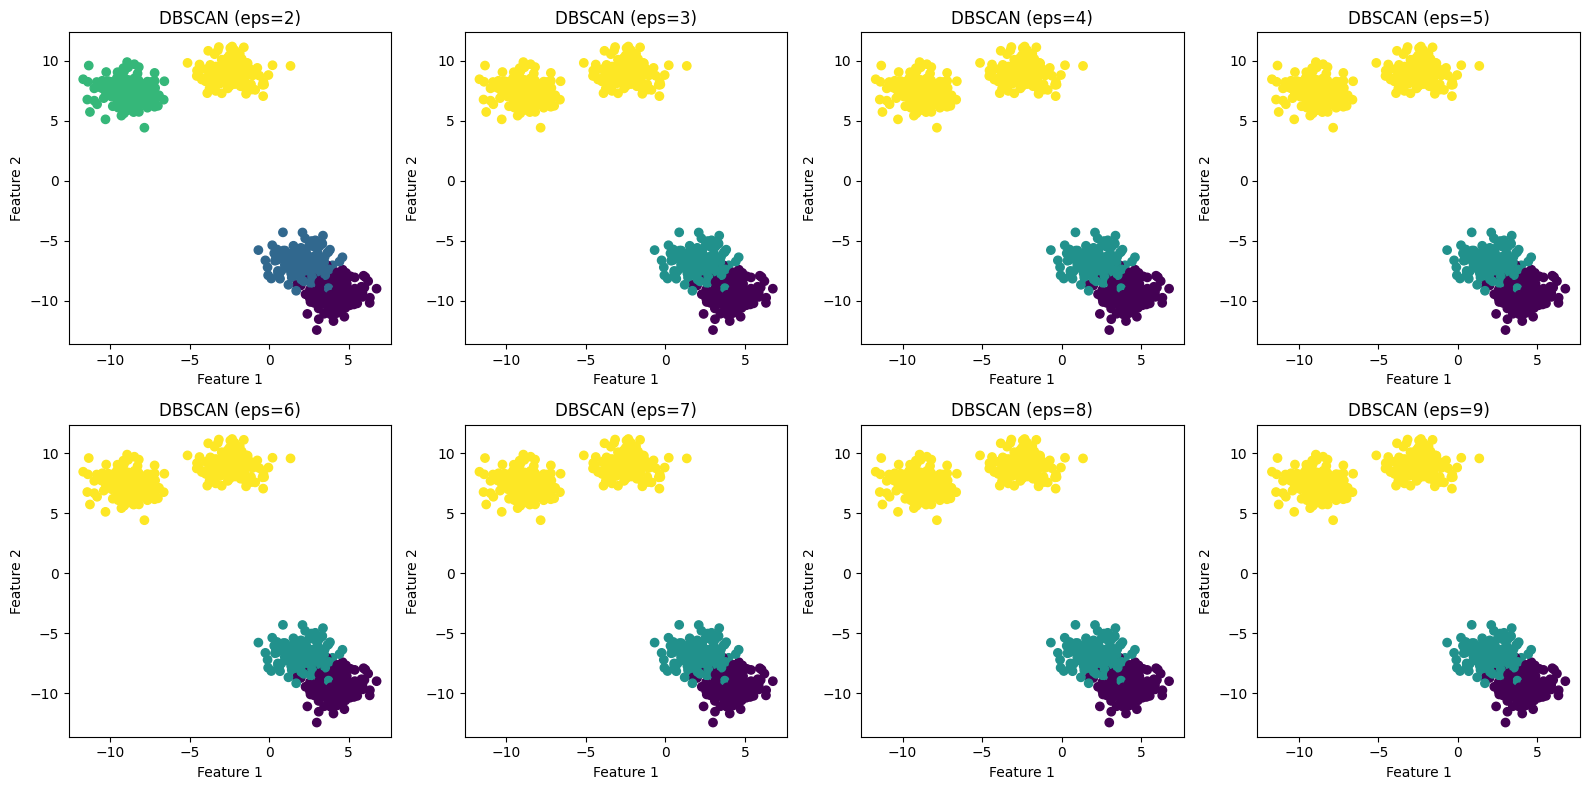

In [ ]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

X,y  = make_blobs(
    n_samples=600,
    n_features=3,
    centers=4,
    cluster_std=1,
    center_box=(-10,10),
    shuffle=True,
    random_state=42

)
# Create a figure and a 2x4 grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))

# Flatten the 2D array of axes into a 1D array for easy iteration
axes = axes.flatten()

for index, eps in enumerate(range(2, 10)):
    # Fit the model
    scan = DBSCAN(eps=eps, min_samples=5)
    clustering = scan.fit(X)
    labels = clustering.labels_

    # Select the current subplot axis
    ax = axes[index]

    # Plot the data on the current axis
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')

    # Set titles and labels for the specific subplot
    ax.set_title(f"DBSCAN (eps={eps})")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

# Automatically adjust spacing between plots so labels don't overlap
plt.tight_layout()
plt.show()